In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
import matplotlib.pyplot as plt

In [ ]:
cancer = load_breast_cancer()
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['target'] = cancer.target
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [ ]:
# 데이터를 표준화
from sklearn.preprocessing import StandardScaler
cancer_std = StandardScaler().fit_transform(cancer.data)

In [ ]:
# 학습 데이터를 만든거고
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(cancer_std, cancer.target, stratify = cancer.target, test_size=0.2 ,random_state = 2022)

In [ ]:
# 파라미터를 약 2000개 가량으로 줄여본 버전
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([Dense(50, input_shape=(30,), activation = 'relu'),
                Dense(10, activation = 'relu'), Dense(1, activation = 'sigmoid')])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 50)                1550      
                                                                 
 dense_1 (Dense)             (None, 10)                510       
                                                                 
 dense_2 (Dense)             (None, 1)                 11        
                                                                 
Total params: 2,071
Trainable params: 2,071
Non-trainable params: 0
_________________________________________________________________


In [ ]:
# 모델 컴파일 (adam)
model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

In [ ]:
# 모델 학습
hist = model.fit(X_train, y_train, validation_split = 0.2, epochs = 100, batch_size=100)

Epoch 1/100
4/4 [==============================] - 2s 175ms/step - loss: 0.6615 - accuracy: 0.6154 - val_loss: 0.5914 - val_accuracy: 0.7253
Epoch 2/100
4/4 [==============================] - 0s 24ms/step - loss: 0.5714 - accuracy: 0.8214 - val_loss: 0.5205 - val_accuracy: 0.8571
Epoch 3/100
4/4 [==============================] - 0s 32ms/step - loss: 0.4991 - accuracy: 0.8874 - val_loss: 0.4612 - val_accuracy: 0.9011
Epoch 4/100
4/4 [==============================] - 0s 51ms/step - loss: 0.4358 - accuracy: 0.9203 - val_loss: 0.4112 - val_accuracy: 0.9341
Epoch 5/100
4/4 [==============================] - 0s 41ms/step - loss: 0.3862 - accuracy: 0.9368 - val_loss: 0.3683 - val_accuracy: 0.9231
Epoch 6/100
4/4 [==============================] - 0s 15ms/step - loss: 0.3435 - accuracy: 0.9368 - val_loss: 0.3326 - val_accuracy: 0.9231
Epoch 7/100
4/4 [==============================] - 0s 14ms/step - loss: 0.3073 - accuracy: 0.9368 - val_loss: 0.3033 - val_accuracy: 0.9121
Epoch 8/100
4/4 [==

In [ ]:
# 모델 평가
model.evaluate(X_test, y_test)

4/4 [==============================] - 0s 4ms/step - loss: 0.0424 - accuracy: 0.9825


[0.042433492839336395, 0.9824561476707458]

In [ ]:
y_acc = hist.history['accuracy']
y_vloss =  hist.history['val_loss']
xs = np.arange(1, len(y_acc)+1)

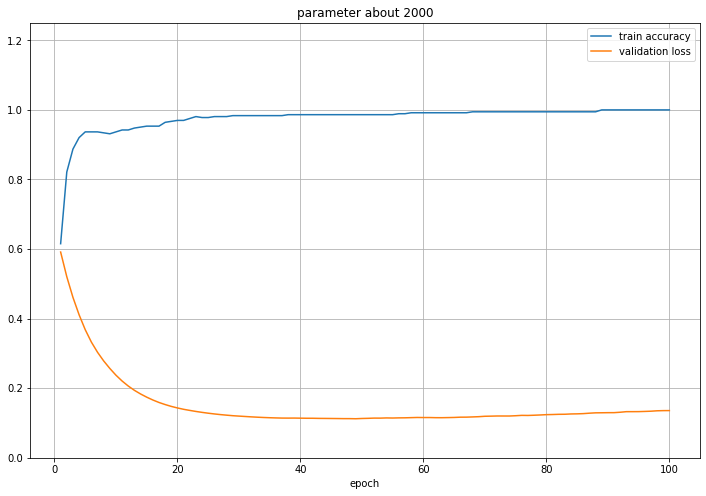

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,8))
plt.plot(xs, y_acc, label='train accuracy')
plt.plot(xs, y_vloss, label='validation loss')
plt.ylim([0,1.25])
plt.xlabel('epoch')
plt.legend()
plt.grid()
plt.title('parameter about 2000')
plt.show()

In [ ]:
# 파라미터를 8000개 이상으로 늘려본 버전
model2 = Sequential([Dense(120, input_shape=(30,), activation = 'relu'),
                Dense(20, activation = 'relu'), Dense(1, activation = 'sigmoid')])

model2.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_3 (Dense)             (None, 120)               3720      
                                                                 
 dense_4 (Dense)             (None, 20)                2420      
                                                                 
 dense_5 (Dense)             (None, 1)                 21        
                                                                 
Total params: 6,161
Trainable params: 6,161
Non-trainable params: 0
_________________________________________________________________


In [ ]:
# 모델 컴파일 (adam)
model2.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

In [ ]:
# 모델 학습
hist2 = model2.fit(X_train, y_train, validation_split = 0.2, epochs = 100, batch_size=100)

Epoch 1/100
4/4 [==============================] - 1s 185ms/step - loss: 0.6001 - accuracy: 0.7280 - val_loss: 0.4816 - val_accuracy: 0.9121
Epoch 2/100
4/4 [==============================] - 0s 26ms/step - loss: 0.4162 - accuracy: 0.9423 - val_loss: 0.3597 - val_accuracy: 0.9121
Epoch 3/100
4/4 [==============================] - 0s 21ms/step - loss: 0.3112 - accuracy: 0.9588 - val_loss: 0.2870 - val_accuracy: 0.9011
Epoch 4/100
4/4 [==============================] - 0s 39ms/step - loss: 0.2454 - accuracy: 0.9560 - val_loss: 0.2399 - val_accuracy: 0.9121
Epoch 5/100
4/4 [==============================] - 0s 27ms/step - loss: 0.2030 - accuracy: 0.9533 - val_loss: 0.2087 - val_accuracy: 0.9121
Epoch 6/100
4/4 [==============================] - 0s 18ms/step - loss: 0.1735 - accuracy: 0.9615 - val_loss: 0.1871 - val_accuracy: 0.9121
Epoch 7/100
4/4 [==============================] - 0s 37ms/step - loss: 0.1518 - accuracy: 0.9670 - val_loss: 0.1710 - val_accuracy: 0.9121
Epoch 8/100
4/4 [==

In [ ]:
# 모델 평가
model2.evaluate(X_test, y_test)

4/4 [==============================] - 0s 3ms/step - loss: 0.0712 - accuracy: 0.9825


[0.07120868563652039, 0.9824561476707458]

In [ ]:
y_acc2 = hist2.history['accuracy']
y_vloss2 =  hist2.history['val_loss']
xs = np.arange(1, len(y_acc)+1)

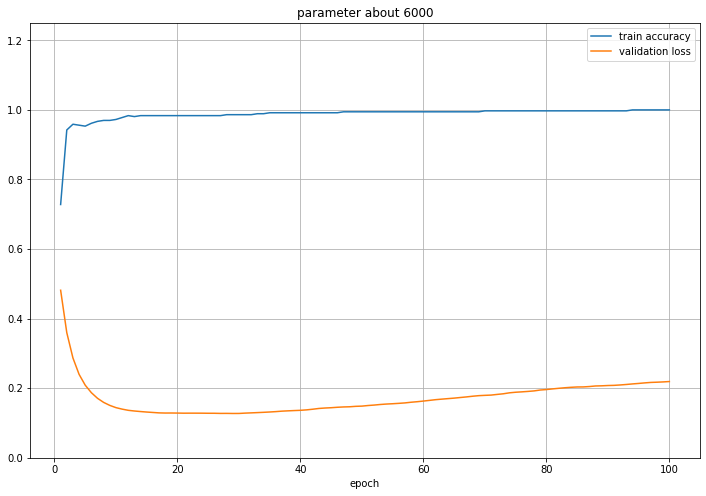

In [ ]:
plt.figure(figsize=(12,8))
plt.plot(xs, y_acc2, label='train accuracy')
plt.plot(xs, y_vloss2, label='validation loss')
plt.ylim([0,1.25])
plt.xlabel('epoch')
plt.legend()
plt.grid()
plt.title('parameter about 6000')
plt.show()

 - epoch 수치만 변경

In [ ]:
# epoch 수치만 변경
X_train3, X_test3, y_train3, y_test3 = train_test_split(cancer.data, cancer.target, stratify = cancer.target, test_size=0.2 ,random_state = 2022)

In [ ]:
model3 = Sequential([Dense(100, input_shape=(30,), activation = 'relu'),
                Dense(24, activation = 'relu'), Dense(1, activation = 'sigmoid')])

model3.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_9 (Dense)             (None, 100)               3100      
                                                                 
 dense_10 (Dense)            (None, 24)                2424      
                                                                 
 dense_11 (Dense)            (None, 1)                 25        
                                                                 
Total params: 5,549
Trainable params: 5,549
Non-trainable params: 0
_________________________________________________________________


In [ ]:
model3.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

In [ ]:
hist3 = model.fit(X_train3, y_train3, validation_split = 0.2, epochs = 40, batch_size=100)

Epoch 1/40
4/4 [==============================] - 0s 53ms/step - loss: 545.0707 - accuracy: 0.3791 - val_loss: 489.8375 - val_accuracy: 0.3516
Epoch 2/40
4/4 [==============================] - 0s 15ms/step - loss: 406.8899 - accuracy: 0.3791 - val_loss: 318.1932 - val_accuracy: 0.3516
Epoch 3/40
4/4 [==============================] - 0s 43ms/step - loss: 239.2396 - accuracy: 0.3791 - val_loss: 116.6873 - val_accuracy: 0.3516
Epoch 4/40
4/4 [==============================] - 0s 23ms/step - loss: 62.8459 - accuracy: 0.3956 - val_loss: 80.5051 - val_accuracy: 0.6484
Epoch 5/40
4/4 [==============================] - 0s 27ms/step - loss: 97.3192 - accuracy: 0.6209 - val_loss: 65.6739 - val_accuracy: 0.6484
Epoch 6/40
4/4 [==============================] - 0s 27ms/step - loss: 41.7787 - accuracy: 0.5467 - val_loss: 28.8150 - val_accuracy: 0.3516
Epoch 7/40
4/4 [==============================] - 0s 16ms/step - loss: 36.4257 - accuracy: 0.3791 - val_loss: 41.2362 - val_accuracy: 0.3516
Epoch 8

In [ ]:
model3.evaluate(X_test3, y_test3)

4/4 [==============================] - 0s 4ms/step - loss: 72.2776 - accuracy: 0.3684


[72.27761840820312, 0.3684210479259491]

In [ ]:
y_acc3 = hist3.history['accuracy']
y_vloss3 =  hist3.history['val_loss']
xs = np.arange(1, len(y_acc)+1)

In [ ]:
plt.figure(figsize=(12,8))
plt.plot(xs, y_acc2, label='train accuracy')
plt.plot(xs, y_vloss2, label='validation loss')
plt.ylim([0,1.25])
plt.xlabel('epoch')
plt.legend()
plt.grid()
plt.title('epoch 40')
plt.show()